<a href="https://colab.research.google.com/github/Mahian-Hoq/ml-notebooks-from-scratch/blob/main/module_11_Decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Classification Model : Decision tree

It uses different questions. Works like a flow chart.

Nodes in this decision tree
1. Root Node
2. Internal Nodes
3. Branches
4. Leaf Nodes (Decision making)

The Root is impure and the Leaf has pure. Our models job is to reduce impurity from the Root node by multiple Inter nodes and branches to Leaf.

**Strengths of Decision Tress**

1. Highly Explainable
2. No Feature Scaling
3. Nonlinear Patterns
4. Excellent Baselines

**Limitaions**

1. Overfitting Tendency
2. High Variance
3. Requires Pruning
4. Struggles with High Dimentions (too much features)

##Entropy, Gini Index and Information Gain

 Our main target is to create **Pure group**.
 * Perfect Purity
 * Maximum Impurity (5 Y, 5 N)
 * Moderate Purity (8 Y, 2 N)

 **Entropy** = Measuring Order

 **Gini Index** = Probability Of Mistake, alternative way of Entropy.

 **Information Gain** = Parent's Impurity - Weighted Avg of Childs Impurity



## Simple Implimentation of Decision Tree

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

###Have to create a small dataset

In [ ]:
data = {
    'Weather': ['Sunny', 'Rainy', 'Sunny', 'Sunny', 'Rainy', 'Rainy', 'Sunny', 'Rainy'],
    'Windy': [0,1,0,1,0,1,0,1],
    'Play': [1,0,1,1,0,0,1,0]
}

df_syn = pd.DataFrame(data)

In [ ]:
df_syn

,Weather,Windy,Play
0,Sunny,0,1
1,Rainy,1,0
2,Sunny,0,1
3,Sunny,1,1
4,Rainy,0,0
5,Rainy,1,0
6,Sunny,0,1
7,Rainy,1,0


In [ ]:
df_syn['Weather_num'] = df_syn['Weather'].map({'Sunny': 1, 'Rainy':0})
X_syn = df_syn[['Weather_num', 'Windy']]
Y_syn = df_syn['Play']
print(X_syn)
print(Y_syn)

   Weather_num  Windy
0            1      0
1            0      1
2            1      0
3            1      1
4            0      0
5            0      1
6            1      0
7            0      1
0    1
1    0
2    1
3    1
4    0
5    0
6    1
7    0
Name: Play, dtype: int64


In [ ]:
tree_syn = DecisionTreeClassifier(max_depth = 3, random_state =42)
tree_syn.fit(X_syn, Y_syn)


DecisionTreeClassifier(max_depth=3, random_state=42)

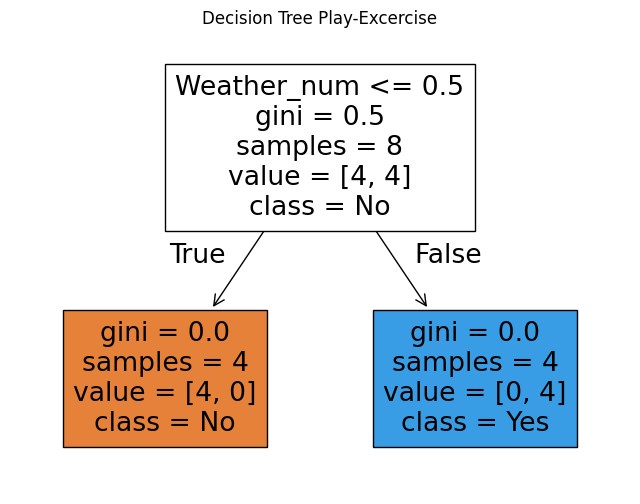

In [ ]:
plt.figure(figsize = (8,6))

plot_tree(
    tree_syn,
    feature_names=['Weather_num', 'Windy'],
    class_names = ['No', 'Yes'],
    filled = True,
    rounded = True
),
plt.title("Decision Tree Play-Excercise")
plt.show()

In [ ]:
# When Weather is Sunny:1 and Windy:1 then the Pred will be

exmp_1 = pd.DataFrame([[1,1]], columns= ['Weather_num', 'Windy'])
pred_1= tree_syn.predict(exmp_1)
print(f"For Sunny and Windy The Play will be {pred_1}")

For Sunny and Windy The Play will be [1]


In [ ]:
# When Weather is Rainy:0 and Not Windy:0 then the Pred will be

exmp_2 = pd.DataFrame([[0,0]], columns= ['Weather_num', 'Windy'])
pred_2= tree_syn.predict(exmp_2)
print(f"For Rainy and not Windy The Play will be {pred_2}")

For Rainy and not Windy The Play will be [0]


In [ ]:
#Here we will create a synthetic dataset, which is much larger then previous one. Here we can see how to make a classification dataset.

from sklearn.datasets import make_classification

X_big_syn, y_big_syn = make_classification(
    n_samples= 400, # Number of rows
    n_features= 5, # Number of Independent columns
    n_informative= 3, # Number of Relevent features, which can give information for the Target Column
    n_redundant= 0, #features generated as combinations of informative features.
    random_state= 42
)

X_train, X_test, y_train, y_test = train_test_split(X_big_syn, y_big_syn, train_size= 0.7, random_state= 42)

X_train.shape, X_test.shape



((280, 5), (120, 5))

In [ ]:
#Training the TREE

deep = DecisionTreeClassifier(random_state=42)

deep.fit(X_train, y_train)

#Training With Max depth

pruned_deep = DecisionTreeClassifier(max_depth= 4,random_state=42)

pruned_deep.fit(X_train, y_train)

# Prediction

y_train_pred_deep = deep.predict(X_train)
y_test_pred_deep = deep.predict(X_test)

y_train_pred_pruned = pruned_deep.predict(X_train)
y_test_pred_pruned = pruned_deep.predict(X_test)


print("Deep-Tree Train accuracy :", round(accuracy_score(y_train, y_train_pred_deep), 3) * 100)
print("Deep-Tree Test accuracy :", round(accuracy_score(y_test, y_test_pred_deep), 3) * 100)

print("Pruned-Deep-Tree Train accuracy :", round(accuracy_score(y_train, y_train_pred_pruned), 3) * 100)
print("Pruned-Deep-Tree Test accuracy :", round(accuracy_score(y_test, y_test_pred_pruned), 3) * 100)

Deep-Tree Train accuracy : 100.0
Deep-Tree Test accuracy : 88.3
Pruned-Deep-Tree Train accuracy : 92.9
Pruned-Deep-Tree Test accuracy : 89.2


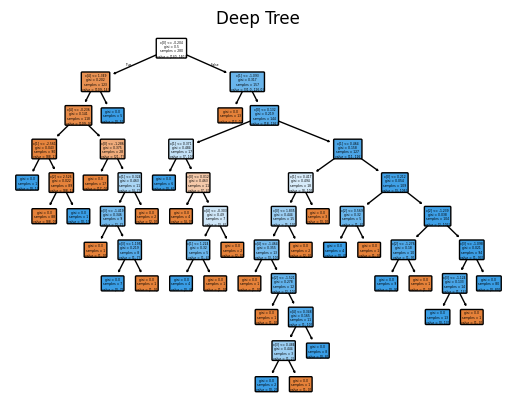

In [ ]:
#plt.figure(figsize= (20,14))
plot_tree(deep, filled= True, rounded= True)
plt.title("Deep Tree")
plt.show()

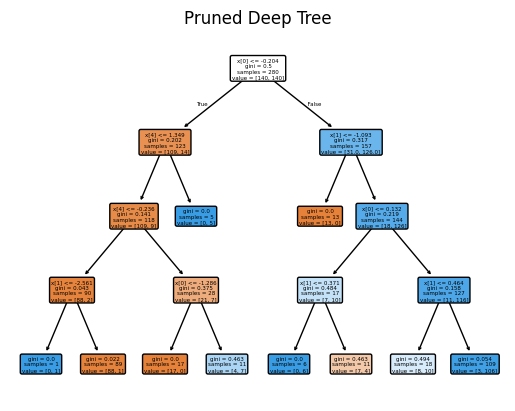

In [ ]:
plot_tree(pruned_deep, filled= True, rounded= True)
plt.title("Pruned Deep Tree")
plt.show()

#Evaluating a Decision Tree Model

In [ ]:
np.random.seed(42)
n_samples = 300

age = np.random.randint(30,80, size= n_samples)
chol = np.random.randint(150,300, size = n_samples)
max_hr = np.random.randint(90,200, size = n_samples)

risk_scr = 0.03 * (age - 40) + 0.02*(chol - 200) - 0.02 * (max_hr - 140) #2.14
prob = 1/ (1 + np.exp(-0.5 * risk_scr)) #

target = (prob / np.median(prob)).astype(int)
#target = (prob > 0.5).astype(int)
#target = np.random.binomial(1, prob)

df_heart = pd.DataFrame({
    'age' : age,
    'chol': chol,
    'max_heartRate': max_hr,
    'HeartDesease' : target
})
df_heart.head()

,age,chol,max_heartRate,HeartDesease
0,68,253,128,1
1,58,233,90,1
2,44,261,92,1
3,72,248,166,1
4,37,242,181,0


In [ ]:
X = df_heart.drop(columns='HeartDesease')
y = df_heart['HeartDesease']

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size= 0.7)

heart_tree = DecisionTreeClassifier(max_depth=4, random_state= 42)
heart_tree.fit(X_train, y_train)

y_pred = heart_tree.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix: ",cm)

acc = accuracy_score(y_test, y_pred)

print("Accuracy: ", acc)

Confusion Matrix:  [[39  7]
 [ 4 40]]
Accuracy:  0.8777777777777778


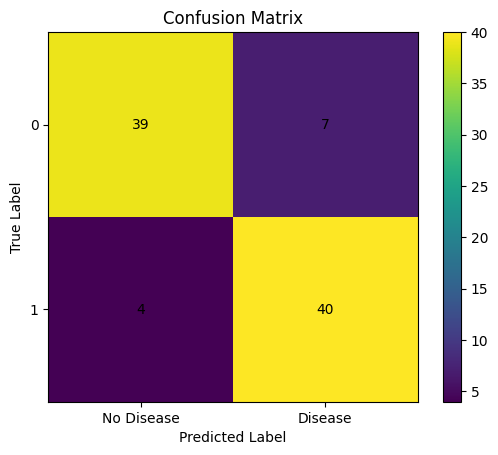

In [ ]:
#Confusion Matrix

fig, ax = plt.subplots()
im = ax.imshow(cm, interpolation = 'nearest')
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")


ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(["No Disease", "Disease"])
ax.set_xticklabels(["No Disease", "Disease"])

for i in range(cm.shape[0]):
  for j in range(cm.shape[1]):
    ax.text(j,i, cm[i,j], ha = 'center', va = 'center')

plt.colorbar(im)
plt.show()

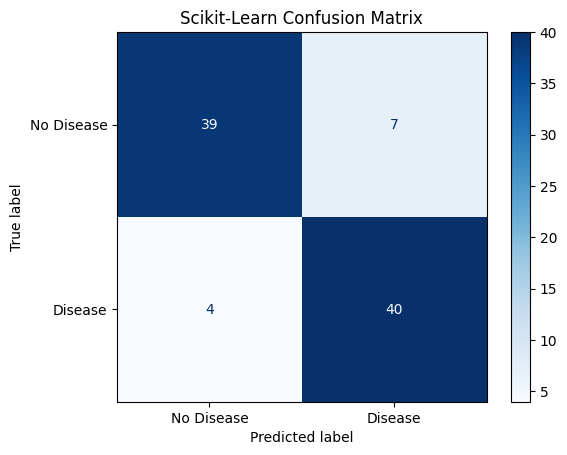

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

# 3. Define display text for your classes
class_names = ['No Disease', 'Disease']

# 4. Create the visual display object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# 5. Plot and customize using matplotlib
disp.plot(cmap=plt.cm.Blues)
plt.title("Scikit-Learn Confusion Matrix")
plt.show()

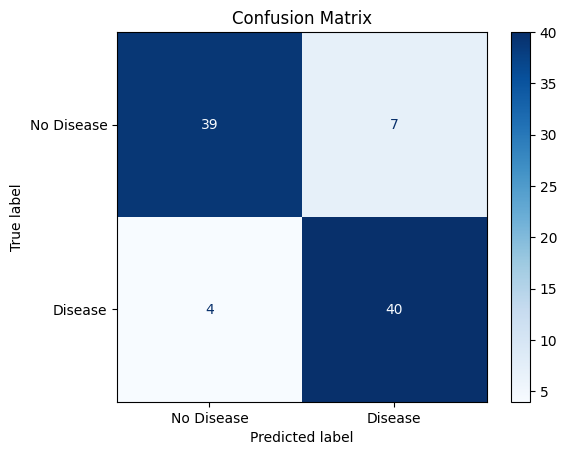

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['No Disease', 'Disease'],
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.show()

In [ ]:
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

In [ ]:
# Accuracy, Precision, Recall

print("Accuracy : ", round(accuracy_score(y_test, y_pred),3)*100, "%")
print("Precision: ", round(precision_score(y_test, y_pred),3)*100, "%")
print("Recall: ", round(recall_score(y_test, y_pred),3)*100, "%")
print("F1 Score: ", round(f1_score(y_test, y_pred),3) * 100, "%")

Accuracy :  87.8 %
Precision:  85.1 %
Recall:  90.9 %
F1 Score:  87.9 %


#ROC AUC curve in decision tree

Probaility Matters.

Classification Threshhold : 0.5 assumption

> Change to high threshold:
* Fewer false alarm
* More missed patients
* Higher precision, lower recall

> Change to Low Threshold
* Fewer missed patient
* More false alarm
* Lower precision, higher recall

**ROC Curve**

For each Threshold point, it will show the True Positive Rate and the False Positive Rate

In ROC Curve there are two axis.

>The Y axis represents **True Positive Rate** or TPR. It is also called Recall.
The equation is TPR = TP / (TP + FN). Not machine , but from totall Positives, how many are they actually Positive.

>The X axix is **False Positive Rate** or FPR. The equation of it is FPR = FP / (FP + TN). Not machine , but from totall Negatives how many are declared Positive by the Machine or model.

**ROC Curve Meanings :**

* Smooth curve bending toward top-left corner <-- Very good Model
* Diagonal line from bottom-left to top-right <-- Random Guessing
* Curve falling below the digonal <-- Broken Model, Predictions are inverted

>The result of ROC Curve is the AUC. If the AUC is 1 Perfect, Flawless Separation. if 0.9 Excellent, strong performance. elseif 0.7 Acceptable, or 0.5 Random, the model is just guessing.

In [ ]:
#Predicted Probability

y_prob = heart_tree.predict_proba(X_test)[:,1]

y_prob[:10]

array([1. , 0. , 0. , 0.9, 0.9, 1. , 1. , 1. , 0. , 0. ])

In [ ]:
fpr,tpr,threshold = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)
print("AUC: ", round(roc_auc,3))

AUC:  0.902


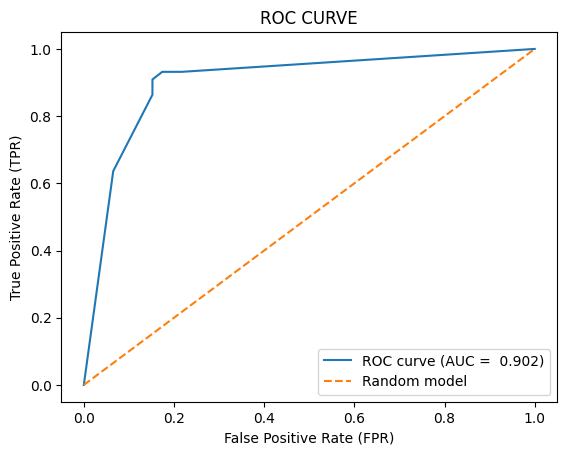

In [ ]:
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc: .3f})')
plt.plot([0,1], [0,1], linestyle='--', label = 'Random model')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC CURVE')
plt.legend()
plt.show()